# PhosphoAtlas AI Agent Benchmark — Novel Kinase Analysis

This notebook analyzes the novel kinases reported by AI agents in the PhosphoAtlas benchmark.

**Workflow:**
1. Extract novel kinases from agent atlas.json files
2. Query each against UniProt REST API
3. Classify by protein function
4. Verify key findings

**Key Result:** Of 510 unique novel entries across 21 agent configurations, only 26 are genuinely novel protein kinases absent from PhosphoAtlas 2.0.

## 1. Agent Performance Summary

In [1]:
import os
import json
import pandas as pd

contributions_path = "contributions"
results = []

def load_summary(agent_name, summary_path):
    with open(summary_path, "r") as f:
        data = json.load(f)
    overview = data.get("overview", {})
    return {
        "agent": agent_name,
        "recall": overview.get("recall"),
        "precision": overview.get("precision"),
        "f1": overview.get("f1"),
        "kinases_found": overview.get("kinases_found"),
        "multi_db_pct": overview.get("multi_db_pct"),
        "peptide_accuracy": overview.get("peptide_accuracy"),
        "atlas_size": overview.get("atlas_size")
    }

for agent_folder in os.listdir(contributions_path):
    if agent_folder == "example":
        continue
    
    agent_path = os.path.join(contributions_path, agent_folder)
    
    # Walk through ALL subfolders looking for summary.json
    for root, dirs, files in os.walk(agent_path):
        if "summary.json" in files:
            summary_path = os.path.join(root, "summary.json")
            # Create a descriptive name using folder + subfolder
            rel_path = os.path.relpath(root, contributions_path)
            agent_name = rel_path.replace("\\", "/").replace("/scores", "")
            results.append(load_summary(agent_name, summary_path))

df = pd.DataFrame(results).sort_values("f1", ascending=False)
print(f"Found {len(df)} agents")
df

Found 38 agents


,agent,recall,precision,f1,kinases_found,multi_db_pct,peptide_accuracy,atlas_size
13,claude_sonnet_naive,0.8727,0.9007,0.8865,404/433,0.0,0.9995,15434
3,andrew_qwen3_235b/results/pipeline_informed,0.9522,0.7994,0.8691,417/433,0.0,0.9794,24818
6,andrew_qwen3_235b_pipeline_informed,0.9522,0.7994,0.8691,417/433,0.0,0.9796,24818
2,andrew_qwen3_235b/results/paper_informed,0.9524,0.7849,0.8606,417/433,2.6,0.9764,25289
5,andrew_qwen3_235b_paper_informed,0.9524,0.7849,0.8606,417/433,2.6,0.9764,25289
14,claude_sonnet_paper_informed,0.8797,0.7937,0.8345,406/433,8.3,0.9914,17715
15,claude_sonnet_pipeline_guided,0.8780,0.7948,0.8343,404/433,8.1,0.9916,17655
25,gpt-5-live-runner/round3,0.8780,0.7753,0.8235,405/433,5.4,0.9972,17983
33,gpt_5_pipeline_guided,0.8780,0.7753,0.8235,405/433,5.4,0.9972,17983
26,gpt-5-live-runner,0.8780,0.7753,0.8235,405/433,5.4,0.9972,17983


## 2. Per-Kinase Analysis

In [2]:
# Look at per_kinase for one agent first to understand structure
with open("contributions/claude_opus_paper_informed/scores/per_kinase.json", "r") as f:
    per_kinase = json.load(f)

print(f"Type: {type(per_kinase)}")
print(f"Number of kinases: {len(per_kinase)}")
print("\nFirst 3 entries:")
for i, (key, val) in enumerate(per_kinase.items()):
    print(f"\n{key}: {json.dumps(val, indent=2)}")
    if i == 2:
        break

Type: <class 'dict'>
Number of kinases: 433

First 3 entries:

AAK1: {
  "gold_entries": 2,
  "agent_entries": 3,
  "tp": 2,
  "fp": 1,
  "fn": 0,
  "precision": 0.6667,
  "recall": 1.0,
  "f1": 0.8,
  "discovered": true
}

ABL1: {
  "gold_entries": 229,
  "agent_entries": 291,
  "tp": 225,
  "fp": 66,
  "fn": 4,
  "precision": 0.7732,
  "recall": 0.9825,
  "f1": 0.8654,
  "discovered": true
}

ABL2: {
  "gold_entries": 22,
  "agent_entries": 24,
  "tp": 22,
  "fp": 2,
  "fn": 0,
  "precision": 0.9167,
  "recall": 1.0,
  "f1": 0.9565,
  "discovered": true
}


In [3]:
per_kinase_all = {}

for agent_folder in os.listdir("contributions"):
    if agent_folder == "example":
        continue
    agent_path = os.path.join("contributions", agent_folder)
    
    for root, dirs, files in os.walk(agent_path):
        if "per_kinase.json" in files:
            rel_path = os.path.relpath(root, "contributions")
            agent_name = rel_path.replace("\\", "/").replace("/scores", "")
            with open(os.path.join(root, "per_kinase.json"), "r") as f:
                per_kinase_all[agent_name] = json.load(f)

print(f"Loaded per_kinase for {len(per_kinase_all)} agents:")
for a in per_kinase_all:
    print(f"  {a}")

Loaded per_kinase for 38 agents:
  andrew_qwen3_235b/qwen_prompt_testing
  andrew_qwen3_235b/results/explicit_prompt
  andrew_qwen3_235b/results/paper_informed
  andrew_qwen3_235b/results/pipeline_informed
  andrew_qwen3_235b
  andrew_qwen3_235b_paper_informed
  andrew_qwen3_235b_pipeline_informed
  claude_opus_iterative/round1
  claude_opus_naive/round2
  claude_opus_naive/round3
  claude_opus_naive
  claude_opus_paper_informed
  claude_opus_pipeline_guided
  claude_sonnet_naive
  claude_sonnet_paper_informed
  claude_sonnet_pipeline_guided
  gemini_3.1_pro_naive
  gemini_3.1_pro_naive/gemini-2.5-flash
  gemini_3.1_pro_naive/gemini-3.0-flash
  gemini_3.1_pro_naive/gemini-3.1-pro
  gemini_3.1_pro_paper_informed
  gemini_3.1_pro_paper_informed/gemini-3.1-pro
  gemini_3.1_pro_pipeline_guided
  gemini_3.1_pro_pipeline_guided/gemini-3.1-pro
  gpt-5-live-runner/round2
  gpt-5-live-runner/round3
  gpt-5-live-runner
  gpt-5-live-runner_paper_informed
  gpt-5-live-runner_pipeline_guided
  gpt5

In [4]:
all_kinase_names = set()
for kinases in per_kinase_all.values():
    all_kinase_names.update(kinases.keys())

missed_by_all = []
for kinase in all_kinase_names:
    missed_by_everyone = all(
        not per_kinase_all[agent].get(kinase, {}).get("discovered", True)
        for agent in per_kinase_all
    )
    if missed_by_everyone:
        missed_by_all.append(kinase)

print(f"Kinases missed by ALL agents: {len(missed_by_all)}")
print(missed_by_all)

Kinases missed by ALL agents: 4
['BCAT2', 'PRKRIR', 'RPS6KC1', 'PRKAR1A']


In [5]:
import numpy as np

print("=== F1 SCORE DISTRIBUTION PER AGENT ===\n")
for agent, kinases in per_kinase_all.items():
    discovered = [v["f1"] for v in kinases.values() if v.get("discovered") and v.get("f1") is not None]
    if not discovered:
        print(f"{agent}: no discovered kinases\n")
        continue
    print(f"{agent}:")
    print(f"  Kinases discovered: {len(discovered)}")
    print(f"  Mean F1:   {np.mean(discovered):.4f}")
    print(f"  Median F1: {np.median(discovered):.4f}")
    print(f"  Std Dev:   {np.std(discovered):.4f}")
    print(f"  % with F1 > 0.8: {sum(1 for x in discovered if x > 0.8)/len(discovered)*100:.1f}%\n")

=== F1 SCORE DISTRIBUTION PER AGENT ===

andrew_qwen3_235b/qwen_prompt_testing:
  Kinases discovered: 391
  Mean F1:   0.5902
  Median F1: 0.6016
  Std Dev:   0.2425
  % with F1 > 0.8: 15.3%

andrew_qwen3_235b/results/explicit_prompt:
  Kinases discovered: 391
  Mean F1:   0.5881
  Median F1: 0.6000
  Std Dev:   0.2429
  % with F1 > 0.8: 15.1%

andrew_qwen3_235b/results/paper_informed:
  Kinases discovered: 419
  Mean F1:   0.8347
  Median F1: 0.8680
  Std Dev:   0.1669
  % with F1 > 0.8: 67.3%

andrew_qwen3_235b/results/pipeline_informed:
  Kinases discovered: 419
  Mean F1:   0.8386
  Median F1: 0.8750
  Std Dev:   0.1649
  % with F1 > 0.8: 68.3%

andrew_qwen3_235b:
  Kinases discovered: 5
  Mean F1:   0.1917
  Median F1: 0.1790
  Std Dev:   0.0390
  % with F1 > 0.8: 0.0%

andrew_qwen3_235b_paper_informed:
  Kinases discovered: 419
  Mean F1:   0.8347
  Median F1: 0.8680
  Std Dev:   0.1669
  % with F1 > 0.8: 67.3%

andrew_qwen3_235b_pipeline_informed:
  Kinases discovered: 419
  Mea

## 3. Peptide Mismatch Analysis

In [6]:
peptide_all = {}

for agent_folder in os.listdir("contributions"):
    if agent_folder == "example":
        continue
    agent_path = os.path.join("contributions", agent_folder)
    
    for root, dirs, files in os.walk(agent_path):
        if "peptide_mismatches.json" in files:
            rel_path = os.path.relpath(root, "contributions")
            agent_name = rel_path.replace("\\", "/").replace("/scores", "")
            with open(os.path.join(root, "peptide_mismatches.json"), "r") as f:
                peptide_all[agent_name] = json.load(f)

print(f"Loaded peptide mismatches for {len(peptide_all)} agents:")
for agent, entries in peptide_all.items():
    print(f"  {agent}: {len(entries)} mismatches")

Loaded peptide mismatches for 38 agents:
  andrew_qwen3_235b/qwen_prompt_testing: 50 mismatches
  andrew_qwen3_235b/results/explicit_prompt: 50 mismatches
  andrew_qwen3_235b/results/paper_informed: 50 mismatches
  andrew_qwen3_235b/results/pipeline_informed: 50 mismatches
  andrew_qwen3_235b: 0 mismatches
  andrew_qwen3_235b_paper_informed: 50 mismatches
  andrew_qwen3_235b_pipeline_informed: 50 mismatches
  claude_opus_iterative/round1: 50 mismatches
  claude_opus_naive/round2: 34 mismatches
  claude_opus_naive/round3: 34 mismatches
  claude_opus_naive: 34 mismatches
  claude_opus_paper_informed: 34 mismatches
  claude_opus_pipeline_guided: 34 mismatches
  claude_sonnet_naive: 7 mismatches
  claude_sonnet_paper_informed: 7 mismatches
  claude_sonnet_pipeline_guided: 7 mismatches
  gemini_3.1_pro_naive: 50 mismatches
  gemini_3.1_pro_naive/gemini-2.5-flash: 0 mismatches
  gemini_3.1_pro_naive/gemini-3.0-flash: 0 mismatches
  gemini_3.1_pro_naive/gemini-3.1-pro: 50 mismatches
  gemini_

In [7]:
def classify_mismatch(gold, agent):
    # Strip underscores and compare core sequence
    gold_core = gold.replace("_", "").upper()
    agent_core = agent.replace("_", "").upper()
    
    if gold_core == agent_core:
        return "case_or_padding_only"
    elif gold_core in agent_core or agent_core in gold_core:
        return "truncated_or_extended"
    else:
        return "sequence_different"

print("=== MISMATCH TYPES PER AGENT ===\n")
for agent, entries in peptide_all.items():
    if not entries:
        continue
    
    categories = {"case_or_padding_only": 0, "truncated_or_extended": 0, "sequence_different": 0}
    
    for entry in entries:
        gold = entry.get("gold_peptide", "")
        agent_pep = entry.get("agent_peptide", "")
        category = classify_mismatch(gold, agent_pep)
        categories[category] += 1
    
    total = len(entries)
    print(f"{agent} ({total} mismatches):")
    for cat, count in categories.items():
        print(f"  {cat}: {count} ({count/total*100:.1f}%)")
    print()

=== MISMATCH TYPES PER AGENT ===

andrew_qwen3_235b/qwen_prompt_testing (50 mismatches):
  case_or_padding_only: 28 (56.0%)
  truncated_or_extended: 9 (18.0%)
  sequence_different: 13 (26.0%)

andrew_qwen3_235b/results/explicit_prompt (50 mismatches):
  case_or_padding_only: 19 (38.0%)
  truncated_or_extended: 15 (30.0%)
  sequence_different: 16 (32.0%)

andrew_qwen3_235b/results/paper_informed (50 mismatches):
  case_or_padding_only: 23 (46.0%)
  truncated_or_extended: 17 (34.0%)
  sequence_different: 10 (20.0%)

andrew_qwen3_235b/results/pipeline_informed (50 mismatches):
  case_or_padding_only: 25 (50.0%)
  truncated_or_extended: 15 (30.0%)
  sequence_different: 10 (20.0%)

andrew_qwen3_235b_paper_informed (50 mismatches):
  case_or_padding_only: 23 (46.0%)
  truncated_or_extended: 17 (34.0%)
  sequence_different: 10 (20.0%)

andrew_qwen3_235b_pipeline_informed (50 mismatches):
  case_or_padding_only: 32 (64.0%)
  truncated_or_extended: 10 (20.0%)
  sequence_different: 8 (16.0%)

cl

In [8]:
from collections import Counter

all_mismatch_kinases = []
for agent, entries in peptide_all.items():
    for entry in entries:
        all_mismatch_kinases.append(entry.get("kinase", "unknown"))

kinase_counts = Counter(all_mismatch_kinases)
print("=== KINASES WITH MOST PEPTIDE MISMATCHES (across all agents) ===\n")
for kinase, count in kinase_counts.most_common(15):
    print(f"  {kinase}: {count} agents got peptide wrong")

=== KINASES WITH MOST PEPTIDE MISMATCHES (across all agents) ===

  PRKACA: 72 agents got peptide wrong
  ABL1: 55 agents got peptide wrong
  CDK1: 42 agents got peptide wrong
  CDK2: 41 agents got peptide wrong
  CSNK2A1: 41 agents got peptide wrong
  CSNK2B: 38 agents got peptide wrong
  SRC: 37 agents got peptide wrong
  LATS1: 22 agents got peptide wrong
  PLK1: 21 agents got peptide wrong
  PRKCA: 20 agents got peptide wrong
  AURKB: 20 agents got peptide wrong
  GSK3B: 19 agents got peptide wrong
  CHEK1: 19 agents got peptide wrong
  MAPK1: 18 agents got peptide wrong
  CAMK2B: 18 agents got peptide wrong


## 4. Figures

### Figure 1: Agent Performance (F1, Precision, Recall)

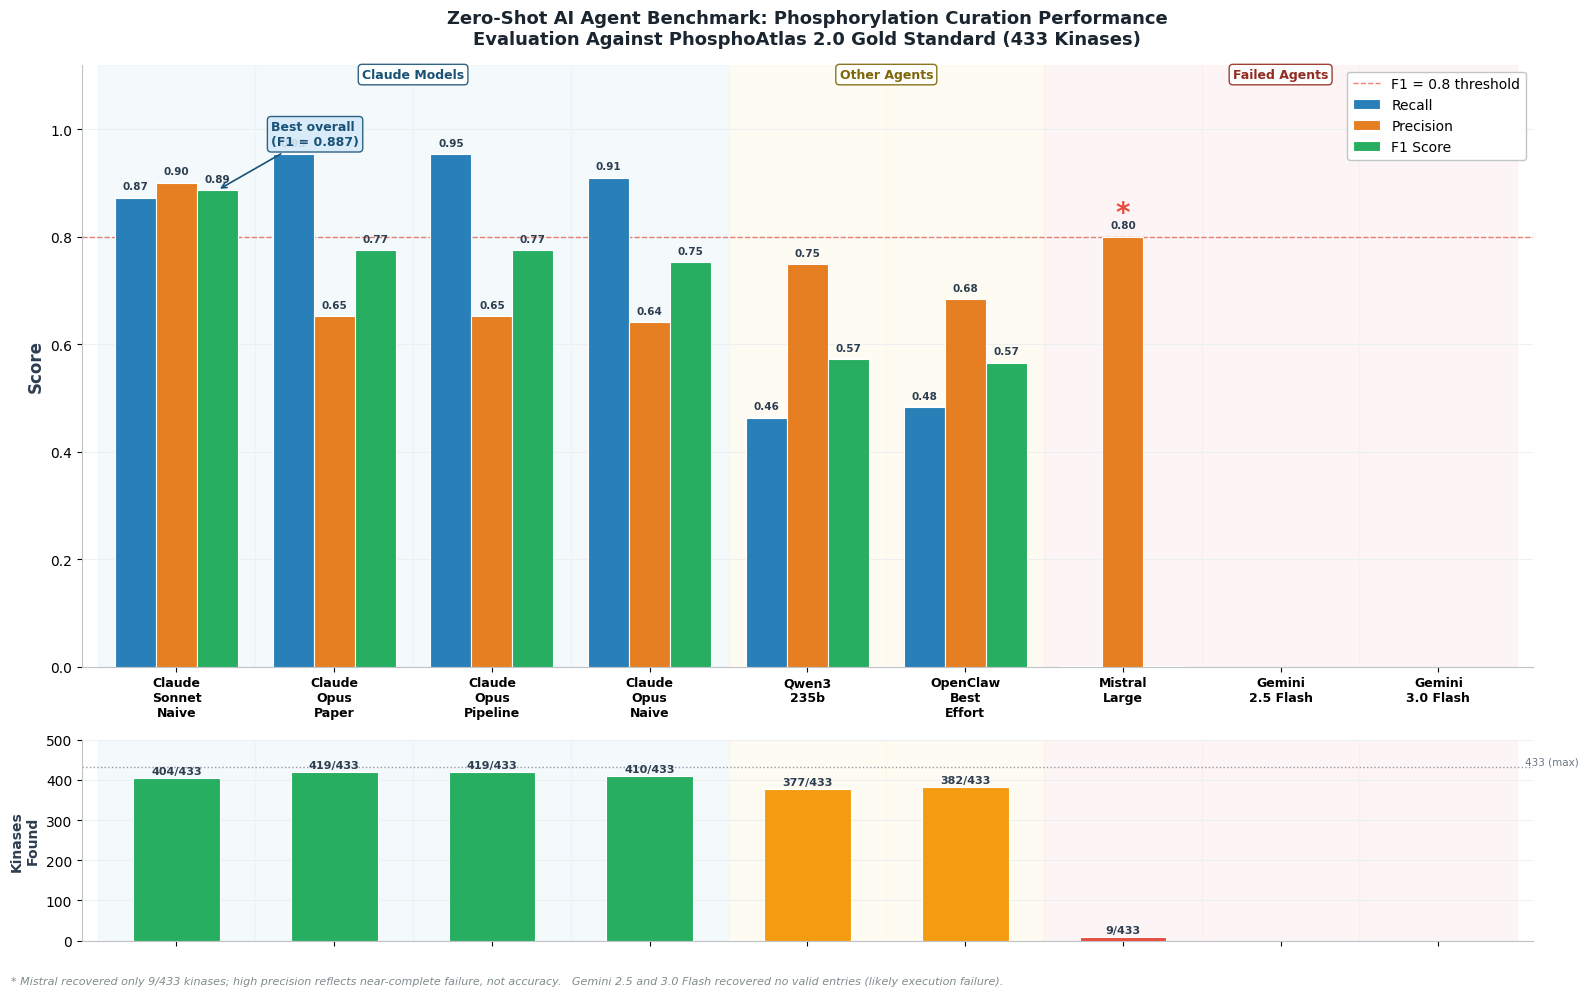

Figure 1 saved at 300 DPI!


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Data ──────────────────────────────────────────────────────────────────────
agents = [
    "Claude\nSonnet\nNaive",
    "Claude\nOpus\nPaper",
    "Claude\nOpus\nPipeline",
    "Claude\nOpus\nNaive",
    "Qwen3\n235b",
    "OpenClaw\nBest\nEffort",
    "Mistral\nLarge",
    "Gemini\n2.5 Flash",
    "Gemini\n3.0 Flash"
]

recall    = [0.8727, 0.9538, 0.9538, 0.9100, 0.4629, 0.4826, 0.0008, 0.0000, 0.0000]
precision = [0.9007, 0.6520, 0.6520, 0.6408, 0.7483, 0.6832, 0.8000, 0.0000, 0.0000]
f1        = [0.8865, 0.7745, 0.7745, 0.7520, 0.5720, 0.5656, 0.0016, 0.0000, 0.0000]
kinases   = [404, 419, 419, 410, 377, 382, 9, 0, 0]

# ── Colors ────────────────────────────────────────────────────────────────────
col_recall    = "#2980B9"
col_precision = "#E67E22"
col_f1        = "#27AE60"
col_bg        = "#F8F9FA"

# Agent background colors (group by model family)
group_colors = ["#EAF4FB"]*4 + ["#FEF9E7"]*2 + ["#FDEDEC"]*3

# ── Setup ─────────────────────────────────────────────────────────────────────
fig, (ax_main, ax_kinase) = plt.subplots(
    2, 1, figsize=(16, 10),
    gridspec_kw={"height_ratios": [3, 1]},
    facecolor="white"
)
fig.patch.set_facecolor("white")

x = np.arange(len(agents))
width = 0.26

# ── Background shading per agent group ───────────────────────────────────────
for i, color in enumerate(group_colors):
    ax_main.axvspan(i - 0.5, i + 0.5, color=color, alpha=0.5, zorder=0)
    ax_kinase.axvspan(i - 0.5, i + 0.5, color=color, alpha=0.5, zorder=0)

# ── Main bars ─────────────────────────────────────────────────────────────────
bars_r = ax_main.bar(x - width, recall,    width, label="Recall",    color=col_recall,    edgecolor="white", linewidth=0.8, zorder=3)
bars_p = ax_main.bar(x,          precision, width, label="Precision", color=col_precision, edgecolor="white", linewidth=0.8, zorder=3)
bars_f = ax_main.bar(x + width,  f1,        width, label="F1 Score",  color=col_f1,        edgecolor="white", linewidth=0.8, zorder=3)

# ── Value labels on bars ──────────────────────────────────────────────────────
for bars in [bars_r, bars_p, bars_f]:
    for rect in bars:
        h = rect.get_height()
        if h > 0.02:
            ax_main.text(
                rect.get_x() + rect.get_width() / 2, h + 0.012,
                f"{h:.2f}", ha="center", va="bottom",
                fontsize=7.5, fontweight="bold", color="#2C3E50"
            )

# ── Reference line ────────────────────────────────────────────────────────────
ax_main.axhline(y=0.8, color="#E74C3C", linestyle="--", linewidth=1, alpha=0.7, zorder=2, label="F1 = 0.8 threshold")

# ── Best agent annotation ─────────────────────────────────────────────────────
ax_main.annotate(
    "Best overall\n(F1 = 0.887)",
    xy=(0 + width, 0.8865), xytext=(0.6, 0.97),
    fontsize=9, color="#1A5276", fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="#1A5276", lw=1.2),
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#D6EAF8", edgecolor="#1A5276", alpha=0.9)
)

# ── Mistral asterisk ──────────────────────────────────────────────────────────
ax_main.text(6, 0.83, "*", fontsize=20, ha="center", color="#E74C3C", fontweight="bold")

# ── Axis formatting ───────────────────────────────────────────────────────────
ax_main.set_xlim(-0.6, len(agents) - 0.4)
ax_main.set_ylim(0, 1.12)
ax_main.set_xticks(x)
ax_main.set_xticklabels(agents, fontsize=9, fontweight="bold")
ax_main.set_ylabel("Score", fontsize=12, fontweight="bold", color="#2C3E50")
ax_main.set_title(
    "Zero-Shot AI Agent Benchmark: Phosphorylation Curation Performance\n"
    "Evaluation Against PhosphoAtlas 2.0 Gold Standard (433 Kinases)",
    fontsize=13, fontweight="bold", color="#1A252F", pad=15
)
ax_main.legend(loc="upper right", fontsize=10, framealpha=0.95, edgecolor="#BDC3C7")
ax_main.spines["top"].set_visible(False)
ax_main.spines["right"].set_visible(False)
ax_main.spines["left"].set_color("#BDC3C7")
ax_main.spines["bottom"].set_color("#BDC3C7")
ax_main.yaxis.grid(True, color="#ECF0F1", zorder=0, linewidth=0.8)
ax_main.set_axisbelow(True)

# ── Group labels above plot ───────────────────────────────────────────────────
for label, pos, color in [
    ("Claude Models", 1.5, "#1A5276"),
    ("Other Agents", 4.5, "#7D6608"),
    ("Failed Agents", 7, "#922B21")
]:
    ax_main.text(pos, 1.095, label, ha="center", fontsize=9,
                 fontweight="bold", color=color,
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                           edgecolor=color, alpha=0.9))

# ── Bottom panel: kinases found ───────────────────────────────────────────────
bar_colors = [col_f1]*4 + ["#F39C12"]*2 + ["#E74C3C"]*3
bars_k = ax_kinase.bar(x, kinases, 0.55, color=bar_colors, edgecolor="white", linewidth=0.8, zorder=3)

for rect, k in zip(bars_k, kinases):
    if k > 0:
        ax_kinase.text(
            rect.get_x() + rect.get_width() / 2,
            k + 5, f"{k}/433",
            ha="center", va="bottom", fontsize=8, fontweight="bold", color="#2C3E50"
        )

ax_kinase.axhline(y=433, color="#2C3E50", linestyle=":", linewidth=1, alpha=0.5, zorder=2)
ax_kinase.text(8.55, 438, "433 (max)", fontsize=7.5, color="#2C3E50", alpha=0.7)
ax_kinase.set_xlim(-0.6, len(agents) - 0.4)
ax_kinase.set_ylim(0, 500)
ax_kinase.set_xticks(x)
ax_kinase.set_xticklabels([])
ax_kinase.set_ylabel("Kinases\nFound", fontsize=10, fontweight="bold", color="#2C3E50")
ax_kinase.spines["top"].set_visible(False)
ax_kinase.spines["right"].set_visible(False)
ax_kinase.spines["left"].set_color("#BDC3C7")
ax_kinase.spines["bottom"].set_color("#BDC3C7")
ax_kinase.yaxis.grid(True, color="#ECF0F1", zorder=0, linewidth=0.8)
ax_kinase.set_axisbelow(True)

# ── Footnote ──────────────────────────────────────────────────────────────────
fig.text(
    0.01, 0.01,
    "* Mistral recovered only 9/433 kinases; high precision reflects near-complete failure, not accuracy.   "
    "Gemini 2.5 and 3.0 Flash recovered no valid entries (likely execution failure).",
    fontsize=8, color="#7F8C8D", style="italic"
)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig("figure1_agent_performance_final.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Figure 1 saved at 300 DPI!")

### Figure 2: Per-Kinase F1 Distribution

C:\Users\river\AppData\Local\Temp\ipykernel_24788\1504842524.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bp = sns.boxplot(
C:\Users\river\AppData\Local\Temp\ipykernel_24788\1504842524.py:132: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, fontsize=10, fontweight="bold")


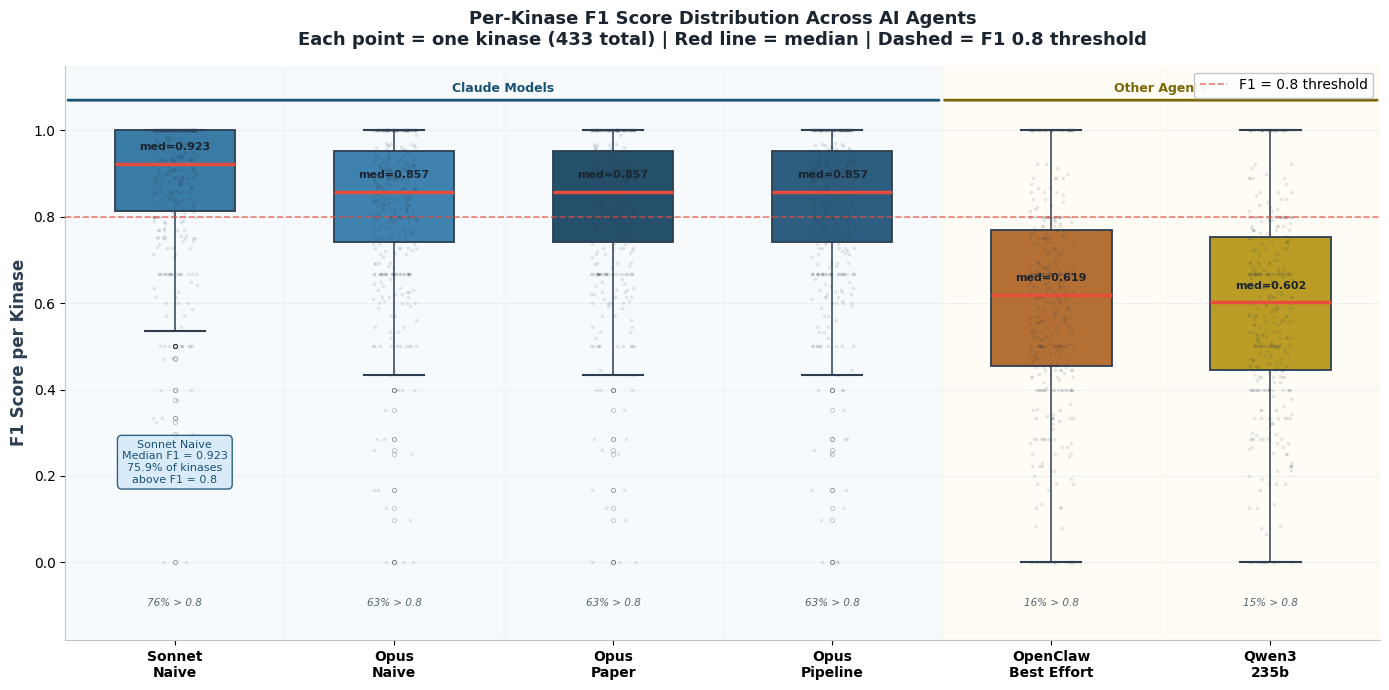

Figure 2 saved at 300 DPI!


In [10]:
# ── Figure 2: Per-Kinase F1 Distribution (Box Plot) ──────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import numpy as np

# ── Build dataframe ───────────────────────────────────────────────────────────
agent_labels = {
    "claude_sonnet_naive":                        "Sonnet\nNaive",
    "claude_opus_paper_informed":                 "Opus\nPaper",
    "claude_opus_pipeline_guided":                "Opus\nPipeline",
    "claude_opus_naive":                          "Opus\nNaive",
    "andrew_qwen3_235b/qwen_prompt_testing":      "Qwen3\n235b",
    "openclaw_live_best_effort":                  "OpenClaw\nBest Effort",
}

group_colors = {
    "Sonnet\nNaive":          "#2980B9",
    "Opus\nPaper":            "#1A5276",
    "Opus\nPipeline":         "#1F618D",
    "Opus\nNaive":            "#2E86C1",
    "Qwen3\n235b":            "#D4AC0D",
    "OpenClaw\nBest Effort":  "#CA6F1E",
}

box_data = []
for agent, kinases in per_kinase_all.items():
    if agent not in agent_labels:
        continue
    label = agent_labels[agent]
    for kinase, vals in kinases.items():
        if vals.get("discovered") and vals.get("f1") is not None:
            box_data.append({
                "Agent": label,
                "F1":    vals["f1"],
                "gold":  vals.get("gold_entries", 0)
            })

df_box = pd.DataFrame(box_data)

# Sort by median F1 descending
order = (df_box.groupby("Agent")["F1"]
         .median()
         .sort_values(ascending=False)
         .index.tolist())

palette = [group_colors[a] for a in order]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7), facecolor="white")
fig.patch.set_facecolor("white")

# Background shading
for i in range(len(order)):
    ax.axvspan(i - 0.5, i + 0.5,
               color="#EAF4FB" if i < 4 else "#FEF9E7",
               alpha=0.4, zorder=0)

# Box plot
bp = sns.boxplot(
    data=df_box, x="Agent", y="F1", order=order,
    palette=palette,
    width=0.55, linewidth=1.3,
    flierprops=dict(marker="o", markersize=3, alpha=0.35,
                    markeredgewidth=0.5),
    boxprops=dict(edgecolor="#2C3E50"),
    whiskerprops=dict(color="#2C3E50", linewidth=1.1),
    capprops=dict(color="#2C3E50", linewidth=1.5),
    medianprops=dict(color="#E74C3C", linewidth=2.5),
    ax=ax
)

# Individual data points (strip)
sns.stripplot(
    data=df_box, x="Agent", y="F1", order=order,
    color="#2C3E50", alpha=0.12, size=2.5,
    jitter=True, ax=ax, zorder=2
)

# F1 = 0.8 threshold line
ax.axhline(y=0.8, color="#E74C3C", linestyle="--",
           linewidth=1.2, alpha=0.7, zorder=3,
           label="F1 = 0.8 threshold")

# Median labels above each box
for i, agent in enumerate(order):
    vals   = df_box[df_box["Agent"] == agent]["F1"]
    median = vals.median()
    mean   = vals.mean()
    pct    = (vals > 0.8).mean() * 100
    ax.text(i, median + 0.032, f"med={median:.3f}",
            ha="center", fontsize=8, fontweight="bold",
            color="#1A252F", zorder=5)
    ax.text(i, -0.1, f"{pct:.0f}% > 0.8",
            ha="center", fontsize=7.5, color="#566573",
            fontstyle="italic", zorder=5)

# Group bracket — Claude models
ax.annotate("", xy=(3.5, 1.07), xytext=(-0.5, 1.07),
            arrowprops=dict(arrowstyle="-", color="#1A5276", lw=2))
ax.text(1.5, 1.09, "Claude Models", ha="center", fontsize=9,
        fontweight="bold", color="#1A5276")

# Group bracket — Other agents
ax.annotate("", xy=(5.5, 1.07), xytext=(3.5, 1.07),
            arrowprops=dict(arrowstyle="-", color="#7D6608", lw=2))
ax.text(4.5, 1.09, "Other Agents", ha="center", fontsize=9,
        fontweight="bold", color="#7D6608")

# ── Stats annotation box ──────────────────────────────────────────────────────
stats_text = (
    "Sonnet Naive\n"
    "Median F1 = 0.923\n"
    "75.9% of kinases\nabove F1 = 0.8"
)
ax.text(0, 0.18, stats_text, fontsize=8, color="#1A5276",
        ha="center", va="bottom",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#D6EAF8",
                  edgecolor="#1A5276", alpha=0.9))

# ── Formatting ────────────────────────────────────────────────────────────────
ax.set_ylim(-0.18, 1.15)
ax.set_xlabel("")
ax.set_ylabel("F1 Score per Kinase", fontsize=12,
              fontweight="bold", color="#2C3E50")
ax.set_title(
    "Per-Kinase F1 Score Distribution Across AI Agents\n"
    "Each point = one kinase (433 total) | Red line = median | Dashed = F1 0.8 threshold",
    fontsize=13, fontweight="bold", color="#1A252F", pad=15
)
ax.set_xticklabels(order, fontsize=10, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#BDC3C7")
ax.spines["bottom"].set_color("#BDC3C7")
ax.yaxis.grid(True, color="#ECF0F1", zorder=0, linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(loc="upper right", fontsize=10,
          framealpha=0.95, edgecolor="#BDC3C7")

plt.tight_layout()
plt.savefig("figure2_f1_distribution_final.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Figure 2 saved at 300 DPI!")

### Figure 3: Peptide Mismatches

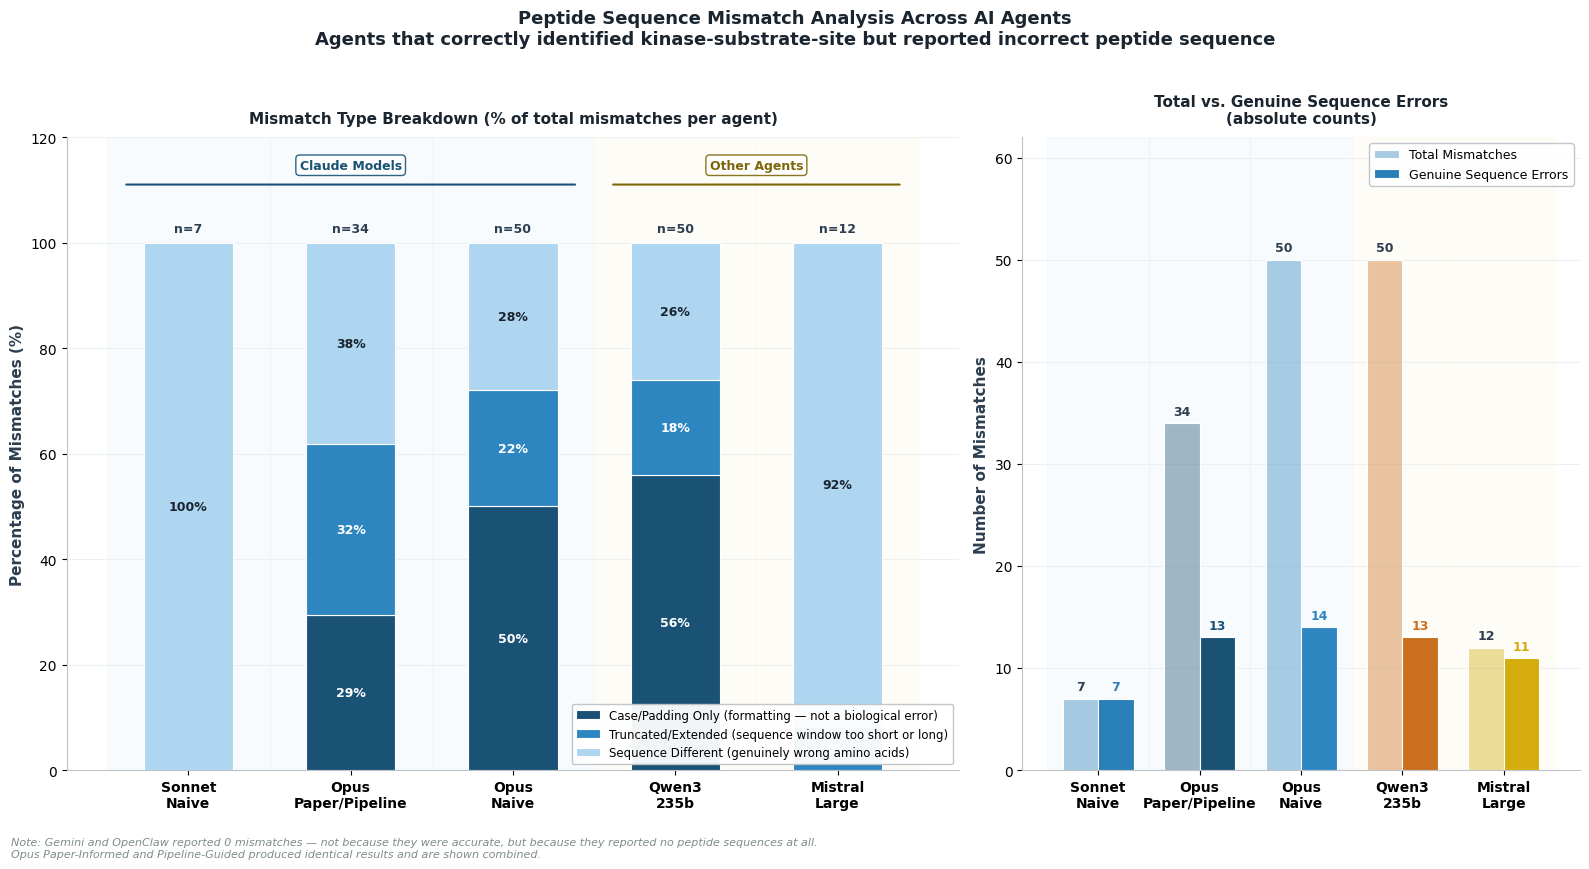

Figure 3 saved!


In [11]:
# ── Figure 3: Peptide Mismatch — cleaned up ───────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

agents   = ["Sonnet\nNaive", "Opus\nPaper/Pipeline", "Opus\nNaive", "Qwen3\n235b", "Mistral\nLarge"]
total    = [7,  34, 50, 50, 12]
case     = [0,  10, 25, 28,  0]
trunc    = [0,  11, 11,  9,  1]
seqdiff  = [7,  13, 14, 13, 11]

case_pct  = [c/t*100 for c,t in zip(case,  total)]
trunc_pct = [c/t*100 for c,t in zip(trunc, total)]
seq_pct   = [c/t*100 for c,t in zip(seqdiff,total)]

col_case  = "#1A5276"
col_trunc = "#2E86C1"
col_seq   = "#AED6F1"
agent_colors = ["#2980B9", "#1A5276", "#2E86C1", "#CA6F1E", "#D4AC0D"]

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(16, 8),
    gridspec_kw={"width_ratios": [1.6, 1]},
    facecolor="white"
)
fig.patch.set_facecolor("white")
fig.suptitle(
    "Peptide Sequence Mismatch Analysis Across AI Agents\n"
    "Agents that correctly identified kinase-substrate-site but reported incorrect peptide sequence",
    fontsize=13, fontweight="bold", color="#1A252F", y=1.02
)

x = np.arange(len(agents))
width = 0.55

# ── Background shading ────────────────────────────────────────────────────────
for i in range(len(agents)):
    for ax in [ax1, ax2]:
        ax.axvspan(i - 0.5, i + 0.5,
                   color="#EAF4FB" if i < 3 else "#FEF9E7",
                   alpha=0.35, zorder=0)

# ── LEFT: Stacked percentage bar ──────────────────────────────────────────────
ax1.bar(x, case_pct,  width, label="Case/Padding Only (formatting — not a biological error)",
        color=col_case,  edgecolor="white", linewidth=0.8, zorder=3)
ax1.bar(x, trunc_pct, width, bottom=case_pct,
        label="Truncated/Extended (sequence window too short or long)",
        color=col_trunc, edgecolor="white", linewidth=0.8, zorder=3)
ax1.bar(x, seq_pct,   width,
        bottom=[c+t for c,t in zip(case_pct, trunc_pct)],
        label="Sequence Different (genuinely wrong amino acids)",
        color=col_seq,   edgecolor="white", linewidth=0.8, zorder=3)

# Percentage labels INSIDE bars only
for i in range(len(agents)):
    if case_pct[i] > 5:
        ax1.text(i, case_pct[i]/2, f"{case_pct[i]:.0f}%",
                 ha="center", va="center", fontsize=9,
                 fontweight="bold", color="white")
    if trunc_pct[i] > 5:
        ax1.text(i, case_pct[i] + trunc_pct[i]/2,
                 f"{trunc_pct[i]:.0f}%",
                 ha="center", va="center", fontsize=9,
                 fontweight="bold", color="white")
    if seq_pct[i] > 5:
        ax1.text(i, case_pct[i] + trunc_pct[i] + seq_pct[i]/2,
                 f"{seq_pct[i]:.0f}%",
                 ha="center", va="center", fontsize=9,
                 fontweight="bold", color="#1A252F")

# n= labels ABOVE bars (outside graph area)
for i in range(len(agents)):
    ax1.text(i, 102, f"n={total[i]}", ha="center", fontsize=9,
             fontweight="bold", color="#2C3E50")

# Group labels ABOVE plot — outside graph
ax1.text(1, 114, "Claude Models", ha="center", fontsize=9,
         fontweight="bold", color="#1A5276",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                   edgecolor="#1A5276", alpha=0.9))
ax1.annotate("", xy=(-0.4, 111), xytext=(2.4, 111),
             arrowprops=dict(arrowstyle="-", color="#1A5276", lw=1.5))

ax1.text(3.5, 114, "Other Agents", ha="center", fontsize=9,
         fontweight="bold", color="#7D6608",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                   edgecolor="#7D6608", alpha=0.9))
ax1.annotate("", xy=(2.6, 111), xytext=(4.4, 111),
             arrowprops=dict(arrowstyle="-", color="#7D6608", lw=1.5))

ax1.set_xticks(x)
ax1.set_xticklabels(agents, fontsize=10, fontweight="bold")
ax1.set_ylabel("Percentage of Mismatches (%)", fontsize=11,
               fontweight="bold", color="#2C3E50")
ax1.set_ylim(0, 120)
ax1.set_title("Mismatch Type Breakdown (% of total mismatches per agent)",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.spines["left"].set_color("#BDC3C7")
ax1.spines["bottom"].set_color("#BDC3C7")
ax1.yaxis.grid(True, color="#ECF0F1", zorder=0, linewidth=0.8)
ax1.set_axisbelow(True)
ax1.legend(loc="lower right", fontsize=8.5,
           framealpha=0.95, edgecolor="#BDC3C7")

# ── RIGHT: Total vs genuine errors ────────────────────────────────────────────
bar_w = 0.35
total_colors = ["#2980B966", "#1A527666", "#2E86C166", "#CA6F1E66", "#D4AC0D66"]

ax2.bar(x - bar_w/2, total,   bar_w, label="Total Mismatches",
        color=total_colors, edgecolor="white", linewidth=0.8, zorder=3)
ax2.bar(x + bar_w/2, seqdiff, bar_w, label="Genuine Sequence Errors",
        color=agent_colors,  edgecolor="white", linewidth=0.8, zorder=3)

# Value labels ABOVE bars — outside graph
for i in range(len(agents)):
    ax2.text(i - bar_w/2, total[i]   + 0.8, str(total[i]),
             ha="center", fontsize=9, fontweight="bold", color="#2C3E50")
    ax2.text(i + bar_w/2, seqdiff[i] + 0.8, str(seqdiff[i]),
             ha="center", fontsize=9, fontweight="bold", color=agent_colors[i])

ax2.set_xticks(x)
ax2.set_xticklabels(agents, fontsize=10, fontweight="bold")
ax2.set_ylabel("Number of Mismatches", fontsize=11,
               fontweight="bold", color="#2C3E50")
ax2.set_ylim(0, 62)
ax2.set_title("Total vs. Genuine Sequence Errors\n(absolute counts)",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_color("#BDC3C7")
ax2.spines["bottom"].set_color("#BDC3C7")
ax2.yaxis.grid(True, color="#ECF0F1", zorder=0, linewidth=0.8)
ax2.set_axisbelow(True)
ax2.legend(loc="upper right", fontsize=9,
           framealpha=0.95, edgecolor="#BDC3C7")

# ── Footnote BELOW figure — fully outside ─────────────────────────────────────
fig.text(
    0.01, -0.04,
    "Note: Gemini and OpenClaw reported 0 mismatches — not because they were accurate, "
    "but because they reported no peptide sequences at all.\n"
    "Opus Paper-Informed and Pipeline-Guided produced identical results and are shown combined.",
    fontsize=8, color="#7F8C8D", style="italic"
)

plt.tight_layout()
plt.savefig("figure3_peptide_mismatches_final.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Figure 3 saved!")

### Figure 4: Truly Absent vs Attribution Mismatches

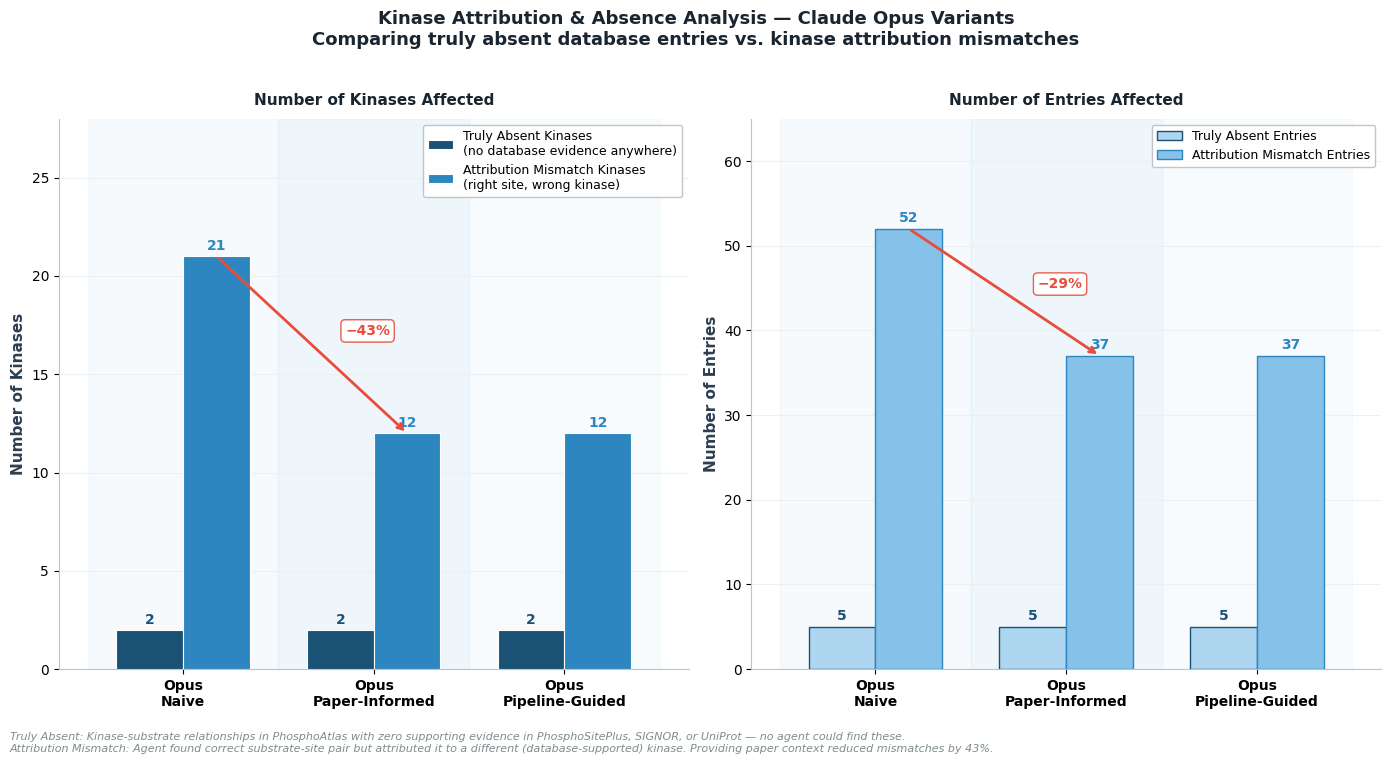

Figure 4 saved!


In [12]:
# ── Figure 4: Truly Absent vs Attribution Mismatches ─────────────────────────
import matplotlib.pyplot as plt
import numpy as np

# ── Data ──────────────────────────────────────────────────────────────────────
agents = ["Opus\nNaive", "Opus\nPaper-Informed", "Opus\nPipeline-Guided"]

truly_absent_kinases  = [2,  2,  2]
attribution_kinases   = [21, 12, 12]
truly_absent_entries  = [5,  5,  5]
attribution_entries   = [52, 37, 37]

col_absent      = "#1A5276"
col_attribution = "#2E86C1"
col_absent_e    = "#AED6F1"
col_attr_e      = "#85C1E9"

x     = np.arange(len(agents))
width = 0.35

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(14, 7), facecolor="white"
)
fig.patch.set_facecolor("white")
fig.suptitle(
    "Kinase Attribution & Absence Analysis — Claude Opus Variants\n"
    "Comparing truly absent database entries vs. kinase attribution mismatches",
    fontsize=13, fontweight="bold", color="#1A252F", y=1.02
)

# ── Background shading ────────────────────────────────────────────────────────
for i in range(len(agents)):
    for ax in [ax1, ax2]:
        ax.axvspan(i - 0.5, i + 0.5,
                   color=["#EAF4FB", "#D6EAF8", "#EBF5FB"][i],
                   alpha=0.4, zorder=0)

# ── LEFT: Kinases affected ────────────────────────────────────────────────────
b1 = ax1.bar(x - width/2, truly_absent_kinases, width,
             label="Truly Absent Kinases\n(no database evidence anywhere)",
             color=col_absent, edgecolor="white", linewidth=0.8, zorder=3)
b2 = ax1.bar(x + width/2, attribution_kinases,  width,
             label="Attribution Mismatch Kinases\n(right site, wrong kinase)",
             color=col_attribution, edgecolor="white", linewidth=0.8, zorder=3)

# Value labels above bars
for rect in b1:
    ax1.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.3,
             str(int(rect.get_height())),
             ha="center", fontsize=10, fontweight="bold", color=col_absent)
for rect in b2:
    ax1.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.3,
             str(int(rect.get_height())),
             ha="center", fontsize=10, fontweight="bold", color=col_attribution)

# Improvement arrow between Opus Naive and Paper
ax1.annotate("", xy=(1 + width/2, 12), xytext=(0 + width/2, 21),
             arrowprops=dict(arrowstyle="->", color="#E74C3C", lw=2))
ax1.text(0.85, 17, "−43%", fontsize=10, fontweight="bold",
         color="#E74C3C",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                   edgecolor="#E74C3C", alpha=0.9))

ax1.set_xticks(x)
ax1.set_xticklabels(agents, fontsize=10, fontweight="bold")
ax1.set_ylabel("Number of Kinases", fontsize=11,
               fontweight="bold", color="#2C3E50")
ax1.set_ylim(0, 28)
ax1.set_title("Number of Kinases Affected",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.spines["left"].set_color("#BDC3C7")
ax1.spines["bottom"].set_color("#BDC3C7")
ax1.yaxis.grid(True, color="#ECF0F1", zorder=0, linewidth=0.8)
ax1.set_axisbelow(True)
ax1.legend(loc="upper right", fontsize=9,
           framealpha=0.95, edgecolor="#BDC3C7")

# ── RIGHT: Entries affected ───────────────────────────────────────────────────
b3 = ax2.bar(x - width/2, truly_absent_entries, width,
             label="Truly Absent Entries",
             color=col_absent_e, edgecolor=col_absent, linewidth=1, zorder=3)
b4 = ax2.bar(x + width/2, attribution_entries,  width,
             label="Attribution Mismatch Entries",
             color=col_attr_e, edgecolor=col_attribution, linewidth=1, zorder=3)

for rect in b3:
    ax2.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.8,
             str(int(rect.get_height())),
             ha="center", fontsize=10, fontweight="bold", color=col_absent)
for rect in b4:
    ax2.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.8,
             str(int(rect.get_height())),
             ha="center", fontsize=10, fontweight="bold", color=col_attribution)

# Improvement arrow
ax2.annotate("", xy=(1 + width/2, 37), xytext=(0 + width/2, 52),
             arrowprops=dict(arrowstyle="->", color="#E74C3C", lw=2))
ax2.text(0.85, 45, "−29%", fontsize=10, fontweight="bold",
         color="#E74C3C",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                   edgecolor="#E74C3C", alpha=0.9))

ax2.set_xticks(x)
ax2.set_xticklabels(agents, fontsize=10, fontweight="bold")
ax2.set_ylabel("Number of Entries", fontsize=11,
               fontweight="bold", color="#2C3E50")
ax2.set_ylim(0, 65)
ax2.set_title("Number of Entries Affected",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_color("#BDC3C7")
ax2.spines["bottom"].set_color("#BDC3C7")
ax2.yaxis.grid(True, color="#ECF0F1", zorder=0, linewidth=0.8)
ax2.set_axisbelow(True)
ax2.legend(loc="upper right", fontsize=9,
           framealpha=0.95, edgecolor="#BDC3C7")

# ── Footnote ──────────────────────────────────────────────────────────────────
fig.text(
    0.01, -0.04,
    "Truly Absent: Kinase-substrate relationships in PhosphoAtlas with zero supporting evidence "
    "in PhosphoSitePlus, SIGNOR, or UniProt — no agent could find these.\n"
    "Attribution Mismatch: Agent found correct substrate-site pair but attributed it to a "
    "different (database-supported) kinase. Providing paper context reduced mismatches by 43%.",
    fontsize=8, color="#7F8C8D", style="italic"
)

plt.tight_layout()
plt.savefig("figure4_attribution_absent.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Figure 4 saved!")

## 5. Novel Kinase Extraction (Updated Data)

After git pull, the repo now contains 21 agent configurations including GPT-5, Gemini 3.1 Pro, and additional prompt variants.

In [13]:
import os
import json
from collections import Counter

# Load gold standard
gold = set()
for folder in sorted(os.listdir("contributions")):
    if folder == "example": continue
    for root, dirs, files in os.walk(os.path.join("contributions", folder)):
        if "per_kinase.json" in files:
            with open(os.path.join(root, "per_kinase.json")) as f:
                gold.update(json.load(f).keys())
            break
    if gold: break

print(f"Gold standard: {len(gold)} kinases\n")

# Extract novel kinases from every agent with a usable atlas.json
skip = {"example", "gemini_2.5_flash_naive", "mistral_large", "andrew_qwen3_235b_naive"}
all_novel = Counter()
agent_source = {}

for folder in sorted(os.listdir("contributions")):
    if folder in skip: continue
    agent_path = os.path.join("contributions", folder)
    if not os.path.isdir(agent_path): continue
    
    # Only use root-level atlas.json (skip rounds/subfolders)
    atlas_path = os.path.join(agent_path, "atlas.json")
    if not os.path.exists(atlas_path): continue
    if os.path.getsize(atlas_path) < 100: continue
    
    with open(atlas_path) as f:
        atlas = json.load(f)
    
    kinases = set()
    for entry in atlas:
        k = entry.get("kinase_gene") or entry.get("KINASE GENE") or entry.get("kinase", "")
        if k: kinases.add(k)
    
    novel = kinases - gold
    print(f"{folder}: {len(kinases)} total, {len(novel)} novel")
    
    for k in novel:
        all_novel[k] += 1
        agent_source.setdefault(k, []).append(folder)

print(f"\n{'='*60}")
print(f"Total unique novel kinases across ALL agents: {len(all_novel)}")
print(f"{'='*60}")

Gold standard: 433 kinases

andrew_qwen3_235b: 5 total, 0 novel
andrew_qwen3_235b_paper_informed: 479 total, 60 novel
andrew_qwen3_235b_pipeline_informed: 478 total, 59 novel
claude_opus_naive: 891 total, 471 novel
claude_opus_paper_informed: 891 total, 471 novel
claude_opus_pipeline_guided: 891 total, 471 novel
claude_sonnet_naive: 537 total, 132 novel
claude_sonnet_paper_informed: 488 total, 81 novel
claude_sonnet_pipeline_guided: 486 total, 81 novel
gemini_3.1_pro_naive: 10 total, 1 novel
gemini_3.1_pro_paper_informed: 32 total, 3 novel
gemini_3.1_pro_pipeline_guided: 134 total, 2 novel
gpt-5-live-runner: 722 total, 315 novel
gpt-5-live-runner_paper_informed: 722 total, 315 novel
gpt-5-live-runner_pipeline_guided: 722 total, 315 novel
gpt_5_naive: 722 total, 315 novel
gpt_5_paper_informed: 722 total, 315 novel
gpt_5_pipeline_guided: 722 total, 315 novel
mistral_large_naive: 10 total, 0 novel
mistral_large_paper_informed: 1 total, 0 novel
mistral_large_pipeline_guided: 3 total, 0 nov

## 6. UniProt REST API Classification

Each of the 510 novel entries was queried against UniProt (gene name, human, reviewed Swiss-Prot).

In [14]:
import requests
import time
import csv

genes = sorted(all_novel.keys())
print(f"Querying {len(genes)} novel kinases against UniProt...\n")

results = []
for i, gene in enumerate(genes):
    clean = gene.strip()
    if not clean or len(clean) > 30:
        results.append({"gene": gene, "accession": "", "gene_names": "", 
                        "protein_name": "SKIPPED - invalid gene name", "keywords": "",
                        "n_agents": all_novel[gene], "agents": "; ".join(agent_source.get(gene, []))})
        continue
    
    query_gene = clean.replace(" ", "+").replace(";", "").replace("/", "")
    
    try:
        url = f"https://rest.uniprot.org/uniprotkb/search?query=(gene:{query_gene}+AND+organism_id:9606+AND+reviewed:true)&format=tsv&fields=accession,gene_names,protein_name,keyword&size=1"
        r = requests.get(url, timeout=10)
        
        if r.ok and len(r.text.strip().split("\n")) > 1:
            parts = r.text.strip().split("\n")[1].split("\t")
            accession = parts[0] if len(parts) > 0 else ""
            gene_names = parts[1] if len(parts) > 1 else ""
            protein_name = parts[2] if len(parts) > 2 else ""
            keywords = parts[3] if len(parts) > 3 else ""
            print(f"  [{i+1}/{len(genes)}] ✅ {gene}: {protein_name[:70]}")
        else:
            accession = gene_names = protein_name = keywords = ""
            print(f"  [{i+1}/{len(genes)}] ❌ {gene}: not found")
    except Exception as e:
        accession = gene_names = protein_name = keywords = ""
        print(f"  [{i+1}/{len(genes)}] ⚠️ {gene}: error - {e}")
    
    results.append({
        "gene": gene, "accession": accession, "gene_names": gene_names,
        "protein_name": protein_name, "keywords": keywords,
        "n_agents": all_novel[gene], "agents": "; ".join(agent_source.get(gene, []))
    })
    time.sleep(0.5)

# Save to CSV
with open("all_novel_kinases_uniprot_UPDATED.csv", "w", newline="", encoding="utf-8") as f:
    w = csv.DictWriter(f, fieldnames=["gene","accession","gene_names","protein_name","keywords","n_agents","agents"])
    w.writeheader()
    w.writerows(results)

found = sum(1 for r in results if r["accession"])
not_found = sum(1 for r in results if not r["accession"])
print(f"\n{'='*60}")
print(f"DONE! {found} found, {not_found} not found")
print(f"Results saved to: all_novel_kinases_uniprot_UPDATED.csv")
print(f"{'='*60}")

Querying 510 novel kinases against UniProt...

  [1/510] ✅ AATK: Serine/threonine-protein kinase LMTK1 (EC 2.7.11.1) (Apoptosis-associa
  [2/510] ✅ ABL: Tyrosine-protein kinase ABL1 (EC 2.7.10.2) (Abelson murine leukemia vi
  [3/510] ✅ ABL, LYN, SRC: Tyrosine-protein kinase ABL1 (EC 2.7.10.2) (Abelson murine leukemia vi
  [4/510] ❌ ABL1, EPHA4: not found
  [5/510] ❌ ABL; in vitro: not found
  [6/510] ✅ ACP1: Low molecular weight phosphotyrosine protein phosphatase (LMW-PTP) (LM
  [7/510] ✅ ACVR2B: Activin receptor type-2B (EC 2.7.11.30) (Activin receptor type IIB) (A
  [8/510] ✅ AK2: Adenylate kinase 2, mitochondrial (AK 2) (EC 2.7.4.3) (ATP-AMP transph
  [9/510] ❌ AKT: not found
  [10/510] ✅ ALPK3: Alpha-protein kinase 3 (EC 2.7.11.1) (Muscle alpha-protein kinase)
  [11/510] ✅ AMPK: 5'-AMP-activated protein kinase subunit beta-1 (AMPK subunit beta-1) (
  [12/510] ❌ AMPK, CaMK1, SIK1: not found
  [13/510] ❌ AMPK, MARK2, SIK1: not found
  [14/510] ✅ APP: Amyloid-beta precursor protein (

### Quick Classification

In [15]:
import csv

# Load the results
results = []
with open("all_novel_kinases_uniprot_UPDATED.csv", "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        results.append(row)

print(f"Total entries: {len(results)}")
found = sum(1 for r in results if r.get("accession", ""))
not_found = sum(1 for r in results if not r.get("accession", ""))
print(f"Found: {found}, Not found: {not_found}")

# Quick classification by protein description
phosphatases = []
kinases_active = []
gtpases = []
rodent = []
multi_kinase = []
in_vitro = []
aliases = []
other = []

for r in results:
    gene = r["gene"]
    desc = r.get("protein_name", "").lower()
    acc = r.get("accession", "")
    
    # Multi-kinase entries (new category from GPT-5)
    if "," in gene and not gene.startswith("autocatalysis"):
        multi_kinase.append(gene)
    # Rodent nomenclature
    elif gene[0].isupper() and len(gene) > 1 and any(c.islower() for c in gene[1:4]) and gene[0] != gene.upper()[0]:
        rodent.append(gene)
    elif len(gene) > 1 and gene[0].isupper() and gene[1].islower() and acc and "kinase" in desc:
        rodent.append(gene)
    # In vitro / alternate tags
    elif "; in vitro" in gene.lower() or "; alternate" in gene.lower():
        in_vitro.append(gene)
    # Autocatalysis
    elif "autocatalysis" in gene.lower():
        other.append(gene)
    # Phosphatases
    elif acc and ("phosphatase" in desc or "3.1.3" in desc):
        phosphatases.append(gene)
    # GTPases
    elif acc and ("gtpase" in desc or "3.6.5" in desc):
        gtpases.append(gene)
    # Active kinases (has EC 2.7.x)
    elif acc and ("2.7.10" in desc or "2.7.11" in desc or "2.7.12" in desc):
        kinases_active.append(gene)
    # Not found = likely alias
    elif not acc:
        aliases.append(gene)
    else:
        other.append(gene)

print(f"\n{'='*60}")
print(f"QUICK CLASSIFICATION OF {len(results)} ENTRIES")
print(f"{'='*60}")
print(f"  Multi-kinase lists (new):  {len(multi_kinase)}")
print(f"  Rodent nomenclature:       {len(rodent)}")
print(f"  Phosphatases:              {len(phosphatases)}")
print(f"  Active kinases (EC 2.7.x): {len(kinases_active)}")
print(f"  In vitro/alternate tags:   {len(in_vitro)}")
print(f"  GTPases:                   {len(gtpases)}")
print(f"  Aliases/not found:         {len(aliases)}")
print(f"  Other/unclassified:        {len(other)}")

Total entries: 510
Found: 317, Not found: 193

QUICK CLASSIFICATION OF 510 ENTRIES
  Multi-kinase lists (new):  84
  Rodent nomenclature:       116
  Phosphatases:              84
  Active kinases (EC 2.7.x): 61
  In vitro/alternate tags:   33
  GTPases:                   3
  Aliases/not found:         91
  Other/unclassified:        38


## 7. Identify Genuinely Novel Kinases

Filter entries with kinase EC numbers (2.7.x) and check against PA2 gold standard.

In [16]:
# Load gold standard kinases
with open("contributions/claude_opus_paper_informed/scores/per_kinase.json") as f:
    gold = set(json.load(f).keys())

# Load the CSV results
import csv
results = []
with open("all_novel_kinases_uniprot_UPDATED.csv", "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        results.append(row)

# Check which of the 61 "active kinases" are truly novel vs already in PA2
truly_novel = []
already_in_pa2 = []
aliases_of_pa2 = []

for r in results:
    gene = r["gene"]
    desc = r.get("protein_name", "").lower()
    acc = r.get("accession", "")
    
    # Only look at entries with kinase EC numbers
    if not acc: continue
    if "2.7.10" not in desc and "2.7.11" not in desc and "2.7.12" not in desc: continue
    
    # Skip multi-kinase comma entries
    if "," in gene: continue
    # Skip in vitro tags
    if "in vitro" in gene.lower(): continue
    
    # Check if it's a rodent duplicate (Title Case)
    upper_gene = gene.upper()
    if upper_gene != gene and upper_gene in gold:
        already_in_pa2.append(f"{gene} → {upper_gene} (rodent naming)")
        continue
    
    # Check if the gene itself is in gold standard
    if gene in gold:
        already_in_pa2.append(f"{gene} (already in PA2)")
        continue
    
    # Check if uppercase version is in gold standard
    if upper_gene in gold:
        already_in_pa2.append(f"{gene} → {upper_gene} (case variant)")
        continue
    
    # This is a genuinely novel active kinase
    truly_novel.append(gene)

print(f"Entries with kinase EC numbers (excluding commas/tags): {len(truly_novel) + len(already_in_pa2)}")
print(f"\nAlready in PA2 under different name: {len(already_in_pa2)}")
for x in sorted(already_in_pa2):
    print(f"  {x}")

print(f"\nTRULY NOVEL active kinases (not in PA2): {len(truly_novel)}")
for x in sorted(truly_novel):
    print(f"  {x}")

Entries with kinase EC numbers (excluding commas/tags): 178

Already in PA2 under different name: 112
  Abl1 → ABL1 (rodent naming)
  Abl2 → ABL2 (rodent naming)
  Acvr1b → ACVR1B (rodent naming)
  Akt1 → AKT1 (rodent naming)
  Akt2 → AKT2 (rodent naming)
  Atm → ATM (rodent naming)
  Atr → ATR (rodent naming)
  Aurka → AURKA (rodent naming)
  Btk → BTK (rodent naming)
  CaMK1 → CAMK1 (rodent naming)
  CaMK2A → CAMK2A (rodent naming)
  CaMK2D → CAMK2D (rodent naming)
  CaMK2G → CAMK2G (rodent naming)
  CaMK4 → CAMK4 (rodent naming)
  Camk1 → CAMK1 (rodent naming)
  Camk2a → CAMK2A (rodent naming)
  Camk2d → CAMK2D (rodent naming)
  Camk2g → CAMK2G (rodent naming)
  Camk4 → CAMK4 (rodent naming)
  Cdk1 → CDK1 (rodent naming)
  Cdk2 → CDK2 (rodent naming)
  Cdk4 → CDK4 (rodent naming)
  Cdk5 → CDK5 (rodent naming)
  Csk → CSK (rodent naming)
  Csnk1a1 → CSNK1A1 (rodent naming)
  Csnk2a1 → CSNK2A1 (rodent naming)
  Dapk1 → DAPK1 (rodent naming)
  Dyrk1a → DYRK1A (rodent naming)
  Dyrk1b →

### Deduplicate: Remove Aliases and Rodent Duplicates

In [17]:
# Check each of the 66 against the gold standard including common aliases
alias_map = {
    "ABL": "ABL1", "BARK": "GRK2", "BARK1": "GRK2", "CAK": "CDK7",
    "CAK complex": "CDK7", "CAMK": "CAMK4", "CAMK2": "CAMK2A",
    "CDC2": "CDK1", "CDKN3": "CDK3", "CaMK1D": "CAMK1D", "CaMK2": "CAMK2A",
    "FAK1": "PTK2", "FAK2": "PTK2B", "GWL": "MASTL", "HRI": "EIF2AK1",
    "IKKA": "CHUK", "IKKB": "IKBKB", "IKKE": "IKBKE", "LKB1": "STK11",
    "MLCK": "MYLK3", "MST1": "STK4", "MST2": "STK3", "MST3": "STK24",
    "PDGFR": "PDGFRB", "PKB": "AKT1", "PKD": "PRKD1", "PKR": "EIF2AK2",
    "RAF": "RAF1", "WSTF": "BAZ1B", "YES": "YES1", "ZIPK": "DAPK3",
    "Bckdk": "BCKDK", "Phkg2": "PHKG2", "Pikfyve": "PIKFYVE",
    "Stk36": "STK36", "Taok3": "TAOK3",
}

genes_66 = [
    "AATK","ABL","ACVR2B","ALPK3","BARK","BARK1","BCKDK","BMPR1A",
    "Bckdk","CAK","CAK complex","CAMK","CAMK2","CCRK","CDC2","CDK11",
    "CDKN3","CSNK2A3","CaMK1D","CaMK2","DCLK1","FAK1","FAK2","GWL",
    "HIPK4","HRI","IKKA","IKKB","IKKE","LKB1","MAST4","MLCK","MST1",
    "MST2","MST3","MUSK","NEK10","NME7","OBSCN","PDGFR","PDPK2P",
    "PHKG2","PIKFYVE","PKB","PKD","PKDCC","PKR","PRPK","Phkg2",
    "Pikfyve","RAF","RIOK1","RIPK4","STK36","Stk36","TAOK3","TNK1",
    "TSSK1","TSSK1B","TSSK2","TSSK3","Taok3","WEE2","WSTF","YES","ZIPK"
]

in_pa2 = []
genuinely_novel = []
not_protein_kinase = []

for gene in genes_66:
    # Check alias
    real_name = alias_map.get(gene, gene.upper())
    
    if real_name in gold:
        in_pa2.append(f"{gene} → {real_name}")
    elif gene.upper() in gold:
        in_pa2.append(f"{gene} → {gene.upper()}")
    elif gene in ["NME7", "PDPK2P", "BCKDK", "PIKFYVE", "Pikfyve", "Bckdk"]:
        not_protein_kinase.append(f"{gene} (metabolic/lipid/pseudogene)")
    else:
        genuinely_novel.append(gene)

print(f"ALREADY IN PA2 (aliases/duplicates): {len(in_pa2)}")
for x in sorted(in_pa2):
    print(f"  {x}")

print(f"\nNOT PROTEIN KINASES: {len(not_protein_kinase)}")
for x in not_protein_kinase:
    print(f"  {x}")

print(f"\nGENUINELY NOVEL: {len(genuinely_novel)}")
for x in sorted(genuinely_novel):
    print(f"  {x}")

ALREADY IN PA2 (aliases/duplicates): 30
  ABL → ABL1
  BARK → GRK2
  BARK1 → GRK2
  CAK complex → CDK7
  CAK → CDK7
  CAMK → CAMK4
  CAMK2 → CAMK2A
  CDC2 → CDK1
  CDKN3 → CDK3
  CaMK2 → CAMK2A
  FAK1 → PTK2
  FAK2 → PTK2B
  GWL → MASTL
  HRI → EIF2AK1
  IKKA → CHUK
  IKKB → IKBKB
  IKKE → IKBKE
  LKB1 → STK11
  MLCK → MYLK3
  MST1 → STK4
  MST2 → STK3
  MST3 → STK24
  PDGFR → PDGFRB
  PKB → AKT1
  PKD → PRKD1
  PKR → EIF2AK2
  RAF → RAF1
  WSTF → BAZ1B
  YES → YES1
  ZIPK → DAPK3

NOT PROTEIN KINASES: 6
  BCKDK (metabolic/lipid/pseudogene)
  Bckdk (metabolic/lipid/pseudogene)
  NME7 (metabolic/lipid/pseudogene)
  PDPK2P (metabolic/lipid/pseudogene)
  PIKFYVE (metabolic/lipid/pseudogene)
  Pikfyve (metabolic/lipid/pseudogene)

GENUINELY NOVEL: 30
  AATK
  ACVR2B
  ALPK3
  BMPR1A
  CCRK
  CDK11
  CSNK2A3
  CaMK1D
  DCLK1
  HIPK4
  MAST4
  MUSK
  NEK10
  OBSCN
  PHKG2
  PKDCC
  PRPK
  Phkg2
  RIOK1
  RIPK4
  STK36
  Stk36
  TAOK3
  TNK1
  TSSK1
  TSSK1B
  TSSK2
  TSSK3
  Taok3
  WEE2


## 8. Verification

Verify alias mappings against UniProt gene_names field.

In [18]:
import requests
import time

alias_map = {
    "ABL": "ABL1", "BARK": "GRK2", "BARK1": "GRK2", "CAK": "CDK7",
    "CAK complex": "CDK7", "CAMK": "CAMK4", "CAMK2": "CAMK2A",
    "CDC2": "CDK1", "CDKN3": "CDK3", "FAK1": "PTK2", "FAK2": "PTK2B",
    "GWL": "MASTL", "HRI": "EIF2AK1", "IKKA": "CHUK", "IKKB": "IKBKB",
    "IKKE": "IKBKE", "LKB1": "STK11", "MLCK": "MYLK3", "MST1": "STK4",
    "MST2": "STK3", "MST3": "STK24", "PDGFR": "PDGFRB", "PKB": "AKT1",
    "PKD": "PRKD1", "PKR": "EIF2AK2", "RAF": "RAF1", "WSTF": "BAZ1B",
    "YES": "YES1", "ZIPK": "DAPK3",
}

print(f"Verifying {len(alias_map)} alias mappings against HGNC via UniProt...\n")

for alias, expected in sorted(alias_map.items()):
    if " " in alias: continue  # skip "CAK complex"
    url = f"https://rest.uniprot.org/uniprotkb/search?query=(gene:{alias}+AND+organism_id:9606+AND+reviewed:true)&format=tsv&fields=gene_names&size=1"
    r = requests.get(url, timeout=10)
    lines = r.text.strip().split("\n")
    if len(lines) > 1:
        gene_names = lines[1]
        if expected in gene_names:
            print(f"  ✅ {alias} → {expected} (confirmed: {gene_names[:60]})")
        else:
            print(f"  ⚠️ {alias} → {expected} NOT in gene names: {gene_names[:60]}")
    else:
        print(f"  ❌ {alias}: not found in UniProt")
    time.sleep(0.3)

Verifying 29 alias mappings against HGNC via UniProt...

  ✅ ABL → ABL1 (confirmed: ABL1 ABL JTK7)
  ✅ BARK → GRK2 (confirmed: GRK2 ADRBK1 BARK BARK1)
  ✅ BARK1 → GRK2 (confirmed: GRK2 ADRBK1 BARK BARK1)
  ✅ CAK → CDK7 (confirmed: CDK7 CAK CAK1 CDKN7 MO15 STK1)
  ✅ CAMK → CAMK4 (confirmed: CAMK4 CAMK CAMK-GR CAMKIV)
  ⚠️ CAMK2 → CAMK2A NOT in gene names: CAMK2B CAM2 CAMK2 CAMKB
  ✅ CDC2 → CDK1 (confirmed: CDK1 CDC2 CDC28A CDKN1 P34CDC2)
  ✅ CDKN3 → CDK3 (confirmed: CDK3 CDKN3)
  ✅ FAK1 → PTK2 (confirmed: PTK2 FAK FAK1)
  ✅ FAK2 → PTK2B (confirmed: PTK2B FAK2 PYK2 RAFTK)
  ✅ GWL → MASTL (confirmed: MASTL GW GWL THC2)
  ✅ HRI → EIF2AK1 (confirmed: EIF2AK1 HRI KIAA1369 PRO1362)
  ✅ IKKA → CHUK (confirmed: CHUK IKKA TCF16)
  ✅ IKKB → IKBKB (confirmed: IKBKB IKKB)
  ✅ IKKE → IKBKE (confirmed: IKBKE IKKE IKKI KIAA0151)
  ✅ LKB1 → STK11 (confirmed: STK11 LKB1 PJS)
  ✅ MLCK → MYLK3 (confirmed: MYLK3 MLCK)
  ✅ MST1 → STK4 (confirmed: STK4 KRS2 MST1)
  ✅ MST2 → STK3 (confirmed: STK3 KRS1 MST2)
 

## 9. Agent Sources for Novel Kinases

Which agents found each of the 66 kinases?

In [19]:
import os
import json
from collections import Counter

# Rebuild agent_source mapping
gold = set()
for folder in sorted(os.listdir("contributions")):
    if folder == "example": continue
    for root, dirs, files in os.walk(os.path.join("contributions", folder)):
        if "per_kinase.json" in files:
            with open(os.path.join(root, "per_kinase.json")) as f:
                gold.update(json.load(f).keys())
            break
    if gold: break

skip = {"example", "gemini_2.5_flash_naive", "mistral_large", "andrew_qwen3_235b_naive"}
agent_source = {}

for folder in sorted(os.listdir("contributions")):
    if folder in skip: continue
    agent_path = os.path.join("contributions", folder)
    if not os.path.isdir(agent_path): continue
    atlas_path = os.path.join(agent_path, "atlas.json")
    if not os.path.exists(atlas_path): continue
    if os.path.getsize(atlas_path) < 100: continue
    with open(atlas_path) as f:
        atlas = json.load(f)
    kinases = set()
    for entry in atlas:
        k = entry.get("kinase_gene") or entry.get("KINASE GENE") or entry.get("kinase", "")
        if k: kinases.add(k)
    novel = kinases - gold
    for k in novel:
        agent_source.setdefault(k, []).append(folder)

# Print sources for the 66 kinases with EC numbers
kinases_66 = [
    "AATK","ABL","ACVR2B","ALPK3","BARK","BARK1","BCKDK","BMPR1A",
    "Bckdk","CAK","CAK complex","CAMK","CAMK2","CCRK","CDC2","CDK11",
    "CDKN3","CSNK2A3","CaMK1D","CaMK2","DCLK1","FAK1","FAK2","GWL",
    "HIPK4","HRI","IKKA","IKKB","IKKE","LKB1","MAST4","MLCK","MST1",
    "MST2","MST3","MUSK","NEK10","NME7","OBSCN","PDGFR","PDPK2P",
    "PHKG2","PIKFYVE","PKB","PKD","PKDCC","PKR","PRPK","Phkg2",
    "Pikfyve","RAF","RIOK1","RIPK4","STK36","Stk36","TAOK3","TNK1",
    "TSSK1","TSSK1B","TSSK2","TSSK3","Taok3","WEE2","WSTF","YES","ZIPK"
]

print(f"{"Gene":<20} {"# Agents":>8}   Sources")
print("="*90)
for gene in sorted(kinases_66):
    sources = agent_source.get(gene, ["unknown"])
    print(f"{gene:<20} {len(sources):>8}   {", ".join(sorted(sources))}")


Gene                 # Agents   Sources
AATK                       14   andrew_qwen3_235b_paper_informed, andrew_qwen3_235b_pipeline_informed, claude_opus_naive, claude_opus_paper_informed, claude_opus_pipeline_guided, claude_sonnet_naive, claude_sonnet_paper_informed, claude_sonnet_pipeline_guided, gpt-5-live-runner, gpt-5-live-runner_paper_informed, gpt-5-live-runner_pipeline_guided, gpt_5_naive, gpt_5_paper_informed, gpt_5_pipeline_guided
ABL                        11   claude_opus_naive, claude_opus_paper_informed, claude_opus_pipeline_guided, claude_sonnet_paper_informed, claude_sonnet_pipeline_guided, gpt-5-live-runner, gpt-5-live-runner_paper_informed, gpt-5-live-runner_pipeline_guided, gpt_5_naive, gpt_5_paper_informed, gpt_5_pipeline_guided
ACVR2B                      5   andrew_qwen3_235b_paper_informed, andrew_qwen3_235b_pipeline_informed, claude_opus_naive, claude_opus_paper_informed, claude_opus_pipeline_guided
ALPK3                      15   andrew_qwen3_235b_paper_inform